<a href="https://colab.research.google.com/github/yavuzomer15/boat_detection/blob/main/image_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision
import numpy as np

In [2]:
x=torch.rand(3, 224, 224)
print("Orijinal boyut: ",x.shape)

Orijinal boyut:  torch.Size([3, 224, 224])


In [3]:
x_reshaped=x.view(-1, 224*224)
print("Düzleştirilmiş boyut: ", x_reshaped.shape)

Düzleştirilmiş boyut:  torch.Size([3, 50176])


In [4]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [5]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,),(0.5,))])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

In [6]:
class BasitAg(nn.Module):
    def __init__(self):
        super().__init__()
        self.duzlestir = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.duzlestir(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BasitAg().to(device)

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
print("Eğitim Başlıyor...")
for data, target in train_loader:
    data, target = data.to(device), target.to(device)

    optimizer.zero_grad()
    output = model(data)
    loss = criterion(output, target)
    loss.backward()
    optimizer.step()

print("1 Epochluk hızlı MNIST eğitimi tamamlandı!")

Eğitim Başlıyor...
1 Epochluk hızlı MNIST eğitimi tamamlandı!


In [10]:
import cv2
import matplotlib.pyplot as plt

In [11]:

img_bgr = cv2.imread('/content/tekne_test.jpg')

In [12]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (640,640))
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
print(f"Orijinal Boyut: {img_bgr.shape}")
print(f"Yeniden Boyutlandırılmış: {img_resized.shape}")

Orijinal Boyut: (410, 550, 3)
Yeniden Boyutlandırılmış: (640, 640, 3)


In [13]:
from PIL import Image
pil_img = Image.fromarray(img_rgb)

In [14]:
veri_artirim_paketi = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),      # %50 ihtimalle resmi yatayda ters çevir
    transforms.RandomRotation(degrees=15),        # Rastgele -15 ile +15 derece arasında döndür
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Parlaklık ve kontrastı rastgele değiştir
    transforms.RandomResizedCrop(size=(640, 640), scale=(0.8, 1.0)) # Resmi rastgele kırp ve 640x640 yap
])

artirilmis_resim_1 = veri_artirim_paketi(pil_img)
artirilmis_resim_2 = veri_artirim_paketi(pil_img)

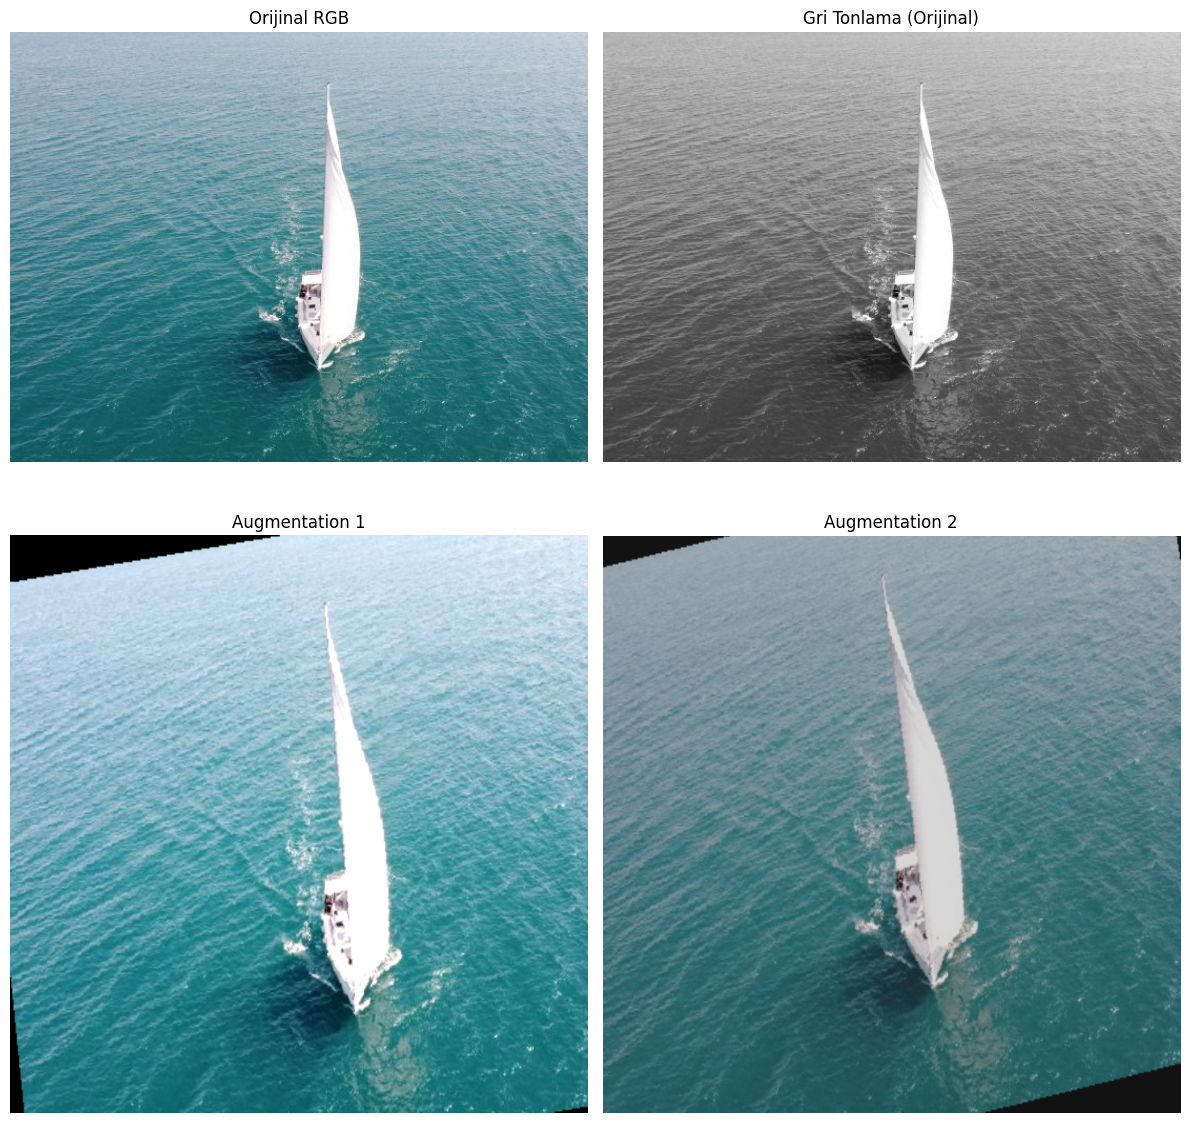

In [15]:
fig, eksenler = plt.subplots(2, 2, figsize=(12, 12))

# Sol Üst: Orijinal RGB Resim
eksenler[0, 0].imshow(img_rgb)
eksenler[0, 0].set_title("Orijinal RGB")
eksenler[0, 0].axis('off')

# Sağ Üst: Gri Tonlamalı Resim
eksenler[0, 1].imshow(img_gray, cmap='gray')
eksenler[0, 1].set_title("Gri Tonlama (Orijinal)")
eksenler[0, 1].axis('off')

# Sol Alt: 1. Artırılmış Alternatif
eksenler[1, 0].imshow(artirilmis_resim_1)
eksenler[1, 0].set_title("Augmentation 1")
eksenler[1, 0].axis('off')

# Sağ Alt: 2. Artırılmış Alternatif
eksenler[1, 1].imshow(artirilmis_resim_2)
eksenler[1, 1].set_title("Augmentation 2")
eksenler[1, 1].axis('off')

plt.tight_layout()
plt.show()

In [16]:
!pip install ultralytics

In [17]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
results = model('/content/tekne_test.jpg')


image 1/1 /content/tekne_test.jpg: 480x640 1 boat, 52.3ms
Speed: 4.2ms preprocess, 52.3ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)


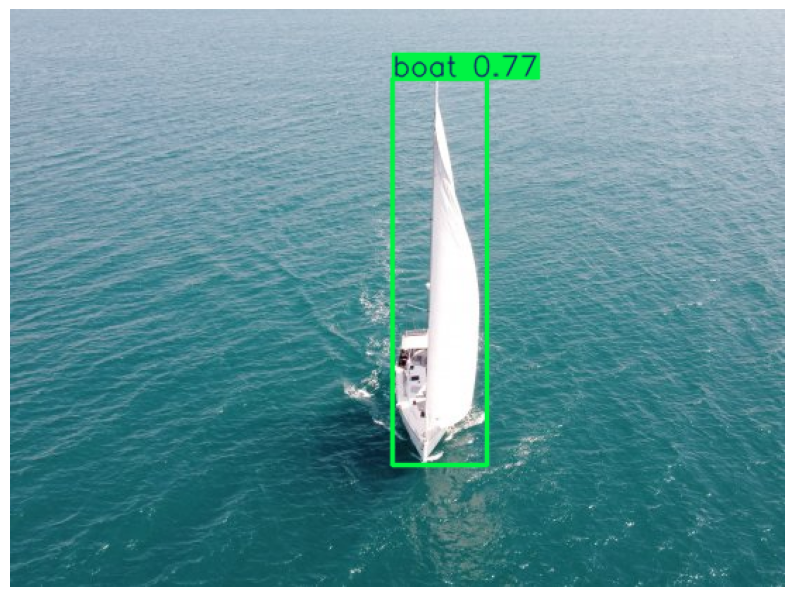

Tespit Edilen: boat | Güven: %76.82 | Koordinatlar: [271, 49, 338, 323]


In [18]:
sonuc_resmi = results[0].plot()
sonuc_rgb = cv2.cvtColor(sonuc_resmi, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 10))
plt.imshow(sonuc_rgb)
plt.axis('off')
plt.show()

for box in results[0].boxes:
  x1, y1, x2, y2 = box.xyxy[0].tolist()
  guven_skoru = box.conf[0].item()
  sinif_id = int(box.cls[0].item())
  sinif_adi = model.names[sinif_id]
  print(f"Tespit Edilen: {sinif_adi} | Güven: %{guven_skoru*100:.2f} | Koordinatlar: [{int(x1)}, {int(y1)}, {int(x2)}, {int(y2)}]")

In [19]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="F60EB8QcE4UdE2oBZ2gY")
project = rf.workspace("class-9byiy").project("boat-uqbnm")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [20]:
from ultralytics import YOLO
model = YOLO('yolov8n.pt')
results = model.train(data='/content/Boat-1/data.yaml', epochs=4, imgsz=640, device=0)

Ultralytics 8.4.86 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Boat-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=4, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, 

KeyboardInterrupt: 

In [ ]:
!pip install sahi

In [ ]:
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
from sahi.utils.cv import read_image
import matplotlib.pyplot as plt

# 1. Modelin Yüklenmesi
# Gün 6'da eğitim sonucu oluşan "best.pt" dosyasını kullanıyoruz.
# Eğer kendi modelin yoksa şimdilik standart "yolov8s.pt" de yazabilirsin.
yolo_model_path = "/content/runs/detect/train/weights/best.pt"

detection_model = AutoDetectionModel.from_pretrained(
    model_type='yolov8',
    model_path=yolo_model_path,
    confidence_threshold=0.3, # %30'dan emin olduğu her şeyi çiz
    device="cuda:0" # Ekran kartını kullanıyoruz
)

# 2. SAHI ile Tarama İşlemi
# Not: Buraya çözünürlüğü yüksek, uzakta tekneler olan bir resim vermelisin
buyuk_resim_yolu = "/content/yuksek_cozunurluklu_deniz.jpg"

result = get_sliced_prediction(
    buyuk_resim_yolu,
    detection_model,
    slice_height=512,         # Resmi 512x512'lik karelere böl
    slice_width=512,
    overlap_height_ratio=0.2, # Dikeyde %20 üst üste bindir (örtüşme)
    overlap_width_ratio=0.2   # Yatayda %20 üst üste bindir
)

# 3. Sonuçları Kaydetme ve Görselleştirme
# SAHI sonuçları otomatik olarak bir klasöre kaydeder
result.export_visuals(export_dir="sahi_sonuclari/")

# Kaydedilen resmi ekranda göstermek için:
sonuc_resmi = read_image("sahi_sonuclari/prediction_visual.png")
plt.figure(figsize=(15, 15))
plt.imshow(sonuc_resmi)
plt.axis('off')
plt.show()

In [ ]:
!pip install easyocr

In [ ]:
import easyocr
import cv2
import matplotlib.pyplot as plt
reader = easyocr.Reader(['en', 'tr'], gpu=True)
resim_yolu = "/content/yazili_tekne_resmi.jpg"
sonuclar = reader.readtext(resim_yolu)
print("--- EASYOCR SONUÇLARI ---")
for (koordinatlar, metin, guven_skoru) in sonuclar:
    print(f"Metin: {metin} | Güven: %{guven_skoru*100:.2f}")

In [ ]:
!pip install paddlepaddle-gpu
!pip install paddleocr

In [21]:
# Önce hata veren mevcut sürümleri kaldırıyoruz
!pip uninstall -y paddleocr paddlex

# Ardından en kararlı olan 2.8.1 sürümünü kuruyoruz
!pip install paddleocr==2.8.1

Found existing installation: paddleocr 2.8.1
Uninstalling paddleocr-2.8.1:
  Successfully uninstalled paddleocr-2.8.1
  Using cached paddleocr-2.8.1-py3-none-any.whl.metadata (19 kB)
Using cached paddleocr-2.8.1-py3-none-any.whl (407 kB)


In [22]:
from paddleocr import PaddleOCR
ocr_motoru = PaddleOCR(use_angle_cls=True, lang='en')
resim_yolu = "/content/yazili_tekne_resmi.jpg"
sonuclar = ocr_motoru.ocr(resim_yolu, cls=True)
print("\n--- PADDLEOCR SONUÇLARI ---")
for line in sonuclar[0]:
    koordinatlar = line[0]
    metin_bilgisi = line[1]
    metin = metin_bilgisi[0]
    guven_skoru = metin_bilgisi[1]

    print(f"Metin: {metin} | Güven: %{guven_skoru*100:.2f}")

download https://paddleocr.bj.bcebos.com/PP-OCRv3/english/en_PP-OCRv3_det_infer.tar to /root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer/en_PP-OCRv3_det_infer.tar


100%|██████████| 4.00M/4.00M [00:16<00:00, 242kiB/s] 


download https://paddleocr.bj.bcebos.com/PP-OCRv4/english/en_PP-OCRv4_rec_infer.tar to /root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer/en_PP-OCRv4_rec_infer.tar


100%|██████████| 10.2M/10.2M [00:19<00:00, 526kiB/s] 


download https://paddleocr.bj.bcebos.com/dygraph_v2.0/ch/ch_ppocr_mobile_v2.0_cls_infer.tar to /root/.paddleocr/whl/cls/ch_ppocr_mobile_v2.0_cls_infer/ch_ppocr_mobile_v2.0_cls_infer.tar


100%|██████████| 2.19M/2.19M [00:14<00:00, 149kiB/s]

[2026/07/02 23:23:23] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=True, use_xpu=False, use_npu=False, use_mlu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_length=25, rec_ch

OSError: In user code:

    File "tools/export_model.py", line 187, in <module>
      main()
    File "tools/export_model.py", line 179, in main
      sub_model_save_path, logger)
    File "tools/export_model.py", line 106, in export_single_model
      paddle.jit.save(model, save_path)
    File "/root/anaconda3/envs/fgd/lib/python3.7/site-packages/paddle/fluid/dygraph/jit.py", line 629, in wrapper
      func(layer, path, input_spec, **configs)
    File "/root/anaconda3/envs/fgd/lib/python3.7/site-packages/decorator.py", line 232, in fun
      return caller(func, *(extras + args), **kw)
    File "/root/anaconda3/envs/fgd/lib/python3.7/site-packages/paddle/fluid/wrapped_decorator.py", line 25, in __impl__
      return wrapped_func(*args, **kwargs)
    File "/root/anaconda3/envs/fgd/lib/python3.7/site-packages/paddle/fluid/dygraph/base.py", line 51, in __impl__
      return func(*args, **kwargs)
    File "/root/anaconda3/envs/fgd/lib/python3.7/site-packages/paddle/fluid/dygraph/jit.py", l